# Neural Network Explanation Stability via Simplex Tree

This notebook demonstrates:
1. Training a neural network on the Pima Indians Diabetes dataset
2. Using SimplexTree to approximate the NN's decision boundary
3. Identifying unstable data points near non-convex boundary regions
4. Showing instability by adding noise and observing prediction flips
5. Creating a convex-constrained tree to stabilize the explanation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
import sys
import os
import warnings
warnings.filterwarnings('ignore')

current_dir = os.getcwd()
project_root = os.path.join(current_dir, '..', '..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load & Preprocess Diabetes Dataset

The Pima Indians Diabetes dataset has 8 numeric features and a binary target.
Several features use 0 as a placeholder for missing values (Glucose, BloodPressure, 
SkinThickness, Insulin, BMI). We replace these with the feature median and normalize 
all features to [0, 1].

In [ ]:
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
df = diabetes.data.copy()
y_raw = diabetes.target

print(f'Dataset shape: {df.shape}')
print(f'Features: {list(df.columns)}')
print(f'Target classes: {y_raw.unique()}')
print(f'\nMissing values per feature:')
print(df.isnull().sum())
print(f'\nFeature statistics before preprocessing:')
df.describe()

Dataset shape: (768, 8)
Features: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']
Target classes: ['tested_positive', 'tested_negative']
Categories (2, object): ['tested_negative', 'tested_positive']

Missing values per feature:
preg    0
plas    0
pres    0
skin    0
insu    0
mass    0
pedi    0
age     0
dtype: int64

Feature statistics before preprocessing:


,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [ ]:
# Features where 0 is a missing-value placeholder
zero_is_missing = ['plas', 'pres', 'skin', 'insu', 'mass']

for col in zero_is_missing:
    if col in df.columns:
        mask = df[col] == 0
        n_missing = mask.sum()
        if n_missing > 0:
            median_val = df.loc[~mask, col].median()
            df.loc[mask, col] = median_val
            print(f'{col}: replaced {n_missing} zeros with median={median_val:.1f}')

# Drop any remaining rows with NaN
n_before = len(df)
df = df.dropna()
print(f'\nDropped {n_before - len(df)} rows with NaN')

X_raw = df.values.astype(np.float64)
y_labels = y_raw.loc[df.index]

# Encode target: tested_positive -> 1, tested_negative -> -1
y = np.where(y_labels == 'tested_positive', 1.0, -1.0)

# Normalize features to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

n_features = X.shape[1]
print(f'\nFinal dataset: {X.shape[0]} samples, {n_features} features')
print(f'Class distribution: +1={np.sum(y == 1)}, -1={np.sum(y == -1)}')
print(f'Feature range after normalization: [{X.min():.3f}, {X.max():.3f}]')

plas: replaced 5 zeros with median=117.0
pres: replaced 35 zeros with median=72.0
skin: replaced 227 zeros with median=29.0
insu: replaced 374 zeros with median=125.0
mass: replaced 11 zeros with median=32.3

Dropped 0 rows with NaN

Final dataset: 768 samples, 8 features
Class distribution: +1=268, -1=500
Feature range after normalization: [0.000, 1.000]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 614 samples
Test:  154 samples


## 2. Build & Train Neural Network

A simple 4-layer feedforward network with ReLU activations and dropout.

In [ ]:
class DiabetesNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def train_nn(model, X_tr, y_tr, X_val, y_val, epochs=200, lr=1e-3, batch_size=64):
    y_tr_01 = ((y_tr + 1) / 2).astype(np.float32)  # {-1,1} -> {0,1}
    y_val_01 = ((y_val + 1) / 2).astype(np.float32)

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr_01, dtype=torch.float32).unsqueeze(1)
    )
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

    best_val_acc = 0
    best_state = None
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(train_ds)

        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_pred_labels = (val_pred.cpu().numpy().flatten() >= 0.5).astype(float)
            val_acc = accuracy_score(y_val_01, val_pred_labels)

        scheduler.step(1 - val_acc)
        history['train_loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1:3d} | loss={epoch_loss:.4f} | val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    print(f'\nBest validation accuracy: {best_val_acc:.4f}')
    return model, history

Epoch  50 | loss=0.4547 | val_acc=0.7338
Epoch 100 | loss=0.4469 | val_acc=0.7403
Epoch 150 | loss=0.4424 | val_acc=0.7403
Epoch 200 | loss=0.4419 | val_acc=0.7403
Epoch 250 | loss=0.4667 | val_acc=0.7403
Epoch 300 | loss=0.4531 | val_acc=0.7403

Best validation accuracy: 0.7468


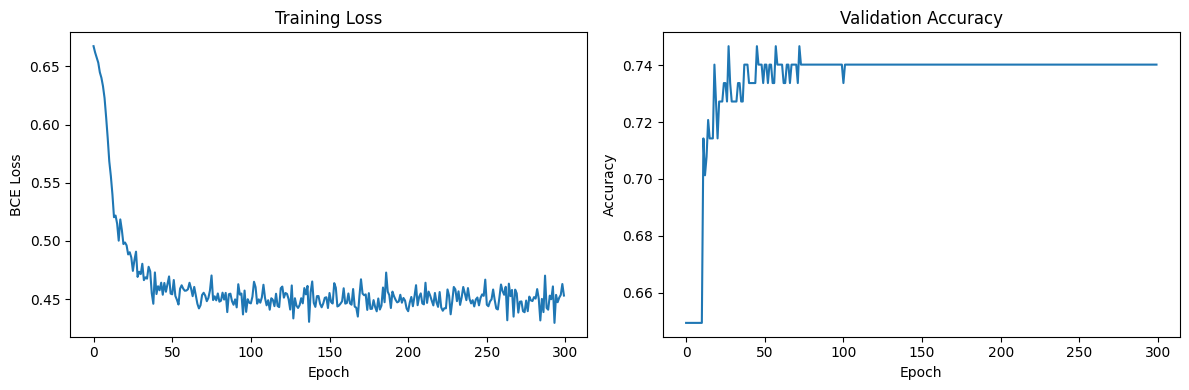

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

nn_model = DiabetesNN(n_features).to(device)
nn_model, history = train_nn(nn_model, X_train, y_train, X_test, y_test, epochs=300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')

ax2.plot(history['val_acc'])
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [ ]:
nn_model.eval()
with torch.no_grad():
    test_probs = nn_model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy().flatten()

y_test_01 = ((y_test + 1) / 2).astype(float)
y_pred_nn = (test_probs >= 0.5).astype(float)
nn_acc = accuracy_score(y_test_01, y_pred_nn)
print(f'Neural Network Test Accuracy: {nn_acc:.4f}')
print()
print(classification_report(y_test_01, y_pred_nn, target_names=['Negative', 'Positive']))

Neural Network Test Accuracy: 0.7468

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.81       100
    Positive       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



## 3. Approximate NN Decision Boundary with SimplexTree

We fill the $[0,1]^n$ cube with random points, pass them through the neural network
to get classification labels, and then train a SimplexTree (with LinearSVC) on these
points. The simplex tree thus approximates the NN's decision surface.

In [ ]:
def nn_predict(model, X_np):
    """Get NN predictions for numpy array of points in [0,1]^n."""
    model.eval()
    with torch.no_grad():
        probs = model(torch.tensor(X_np, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    return np.where(probs >= 0.5, 1.0, -1.0)

In [ ]:
N_FILL = 5000
SUBDIVISION_LEVELS = 3
C_PARAM = 10000

np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_predict(nn_model, X_fill)

print(f'Generated {N_FILL} random points in [0,1]^{n_features}')
print(f'NN predictions: +1={np.sum(y_fill == 1)}, -1={np.sum(y_fill == -1)}')

root_vertices = create_simplex_vertices(n_features)
print(f'\nSimplex vertices ({len(root_vertices)} vertices in {n_features}D):')
for v in root_vertices:
    print(f'  {v}')

Generated 5000 random points in [0,1]^8
NN predictions: +1=4071, -1=929

Simplex vertices (9 vertices in 8D):
  (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
  (8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
  (0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
  (0.0, 0.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0)
  (0.0, 0.0, 0.0, 8.0, 0.0, 0.0, 0.0, 0.0)
  (0.0, 0.0, 0.0, 0.0, 8.0, 0.0, 0.0, 0.0)
  (0.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0, 0.0)
  (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0, 0.0)
  (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.0)


In [ ]:
stc = SimplexTreeClassifier(
    vertices=root_vertices,
    classifier=LinearSVC(C=C_PARAM, max_iter=20000),
    subdivision_levels=SUBDIVISION_LEVELS,
)
stc.fit(X_fill, y_fill)

y_stc_pred = stc.predict(X_fill)
stc_approx_acc = accuracy_score(y_fill, y_stc_pred)
print(f'SimplexTree leaves: {len(stc.leaf_simplexes)}')
print(f'SimplexTree approximation accuracy (vs NN): {stc_approx_acc:.4f}')

# Also check on real test data
y_stc_test = stc.predict(X_test)
y_nn_test = nn_predict(nn_model, X_test)
agreement = accuracy_score(y_nn_test, y_stc_test)
print(f'SimplexTree-NN agreement on real test data: {agreement:.4f}')

SimplexTree leaves: 729
SimplexTree approximation accuracy (vs NN): 0.9790
SimplexTree-NN agreement on real test data: 0.9545


## 4. Identify Unstable Data Points

We find simplices that cross the decision boundary and check for non-convex regions.
Points near non-convex boundary regions are inherently unstable - small perturbations
can flip their classification.

In [ ]:
crossing = stc.identify_crossing_simplices()
print(f'Crossing simplices (on decision boundary): {len(crossing)}')

EPSILON = 0.30
nonconvex_keys = stc.find_nonconvex_simplexes(epsilon=EPSILON)
same_side_keys = stc.find_same_side_simplices()
print(f'Non-convex simplices: {len(nonconvex_keys)}')
print(f'Same-side simplices (removable): {len(same_side_keys)}')

Crossing simplices (on decision boundary): 723
Non-convex simplices: 712
Same-side simplices (removable): 0


In [ ]:
def find_unstable_points(model, X_data, y_data, noise_std=0.02, n_trials=50):
    """
    Find data points whose classification flips easily with small noise.
    For each point, perturb it n_trials times and count how often the 
    prediction flips. Points that flip frequently are unstable.
    """
    flip_counts = np.zeros(len(X_data))
    original_preds = model.predict(X_data)
    
    for trial in range(n_trials):
        noise = np.random.normal(0, noise_std, X_data.shape)
        X_noisy = np.clip(X_data + noise, 0, 1)
        noisy_preds = model.predict(X_noisy)
        flip_counts += (noisy_preds != original_preds).astype(float)
    
    flip_rate = flip_counts / n_trials
    return flip_rate, original_preds

In [ ]:
# Find unstable points in the original NN
nn_flip_rate, nn_preds = find_unstable_points(
    type('NNWrapper', (), {'predict': lambda self, x: nn_predict(nn_model, x)})(),
    X_test, y_test, noise_std=0.02, n_trials=100
)

# Find unstable points in the SimplexTree approximation
stc_flip_rate, stc_preds = find_unstable_points(
    stc, X_test, y_test, noise_std=0.02, n_trials=100
)

nn_unstable_mask = nn_flip_rate > 0.1
stc_unstable_mask = stc_flip_rate > 0.1

print(f'NN unstable points (flip rate > 10%):  {nn_unstable_mask.sum()} / {len(X_test)}')
print(f'STC unstable points (flip rate > 10%): {stc_unstable_mask.sum()} / {len(X_test)}')
print(f'\nNN  flip rate stats: mean={nn_flip_rate.mean():.3f}, max={nn_flip_rate.max():.3f}')
print(f'STC flip rate stats: mean={stc_flip_rate.mean():.3f}, max={stc_flip_rate.max():.3f}')

NN unstable points (flip rate > 10%):  10 / 154
STC unstable points (flip rate > 10%): 18 / 154

NN  flip rate stats: mean=0.026, max=0.490
STC flip rate stats: mean=0.043, max=0.850


## 5. Demonstrate Instability

We pick specific unstable points and show that adding small noise to their features
causes the classification to flip back and forth. This demonstrates that the 
explanation at these points is unreliable.

In [ ]:
# Pick the most unstable points
top_unstable_idx = np.argsort(stc_flip_rate)[-5:][::-1]

print('Most unstable test points (SimplexTree):')
print(f'{"Index":>6} {"Flip Rate":>10} {"Original":>10} {"NN pred":>10}')
print('-' * 40)
for idx in top_unstable_idx:
    print(f'{idx:6d} {stc_flip_rate[idx]:10.2%} {stc_preds[idx]:10.0f} {nn_preds[idx]:10.0f}')

Most unstable test points (SimplexTree):
 Index  Flip Rate   Original    NN pred
----------------------------------------
    45     85.00%          1         -1
    94     68.00%          1          1
   124     52.00%         -1         -1
   102     52.00%          1         -1
   114     51.00%          1          1


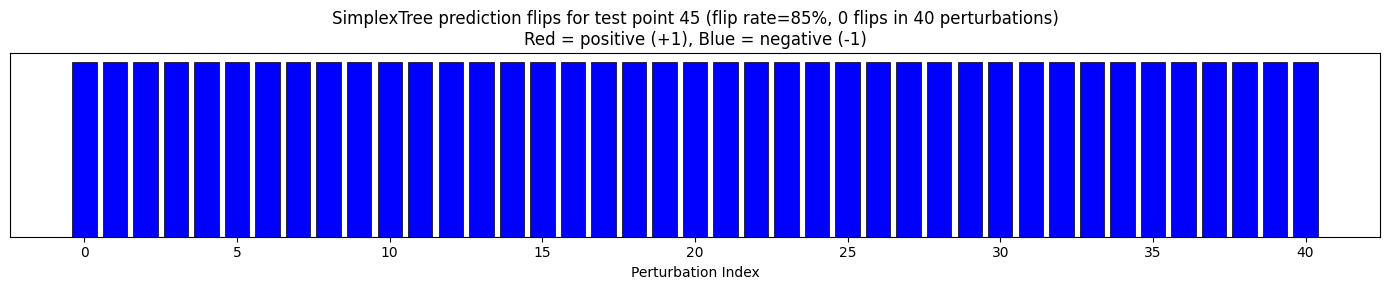

In [ ]:
def demonstrate_instability(model, point, noise_std=0.02, n_perturbations=30, label='Model'):
    """
    Perturb a single point multiple times and track how the prediction changes.
    Returns a sequence of predictions showing flips.
    """
    predictions = []
    original_pred = model.predict(point.reshape(1, -1))[0]
    predictions.append(('original', original_pred))

    for i in range(n_perturbations):
        noise = np.random.normal(0, noise_std, point.shape)
        perturbed = np.clip(point + noise, 0, 1)
        pred = model.predict(perturbed.reshape(1, -1))[0]
        predictions.append((f'noise_{i}', pred))

    return predictions


if len(top_unstable_idx) > 0:
    chosen_idx = top_unstable_idx[0]
    chosen_point = X_test[chosen_idx]

    np.random.seed(0)
    stc_preds_seq = demonstrate_instability(stc, chosen_point, noise_std=0.02, n_perturbations=40)

    pred_values = [p[1] for p in stc_preds_seq]
    flips = sum(1 for i in range(1, len(pred_values)) if pred_values[i] != pred_values[i-1])

    fig, ax = plt.subplots(figsize=(14, 3))
    colors = ['red' if p == 1 else 'blue' for p in pred_values]
    ax.bar(range(len(pred_values)), [1]*len(pred_values), color=colors, edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Perturbation Index')
    ax.set_title(f'SimplexTree prediction flips for test point {chosen_idx} '
                 f'(flip rate={stc_flip_rate[chosen_idx]:.0%}, {flips} flips in {len(pred_values)-1} perturbations)\n'
                 f'Red = positive (+1), Blue = negative (-1)')
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print('No unstable points found. Try increasing noise_std or lowering the threshold.')

## 6. Stabilize Explanation via Convex-Constrained Tree

We iteratively remove non-convex simplices and re-fit the classifier.
This forces the decision boundary to be locally convex, producing a more
stable explanation. The process is:
1. Identify non-convex and same-side simplices
2. Remove them (merge siblings back into parent)
3. Re-fit the linear classifier
4. Repeat until the boundary stabilizes

In [ ]:
def build_convex_constrained_tree(X_data, y_data, n_features, 
                                   subdivision_levels=3, C=10000, 
                                   epsilon=0.30, max_iterations=10):
    """
    Build a simplex tree and iteratively remove non-convex simplices
    until the explanation stabilizes (all remaining boundary simplices are convex).
    """
    root_vertices = create_simplex_vertices(n_features)
    
    model = SimplexTreeClassifier(
        vertices=root_vertices,
        classifier=LinearSVC(C=C, max_iter=20000),
        subdivision_levels=subdivision_levels,
    )
    model.fit(X_data, y_data)
    
    history = []
    
    for iteration in range(max_iterations):
        nonconvex_keys = model.find_nonconvex_simplexes(epsilon=epsilon)
        same_side_keys = model.find_same_side_simplices()
        combined_keys = nonconvex_keys.union(same_side_keys)
        
        n_leaves = len(model.tree.get_leaves())
        
        history.append({
            'iteration': iteration,
            'leaves': n_leaves,
            'nonconvex': len(nonconvex_keys),
            'same_side': len(same_side_keys),
            'to_remove': len(combined_keys),
        })
        
        print(f'Iteration {iteration}: {n_leaves} leaves, '
              f'{len(nonconvex_keys)} non-convex, '
              f'{len(same_side_keys)} same-side, '
              f'{len(combined_keys)} to remove')
        
        if len(combined_keys) == 0:
            print('Converged: no more non-convex or same-side simplices.')
            break
        
        removed = 0
        for key in combined_keys:
            if model.tree.remove_by_leaf_key(key):
                removed += 1
        
        if removed == 0:
            print('No simplices could be removed. Stopping.')
            break
        
        model._build_node_lookup()
        model.fit(X_data, y_data)
    
    return model, history

In [ ]:
stc_convex, convex_history = build_convex_constrained_tree(
    X_fill, y_fill, n_features,
    subdivision_levels=SUBDIVISION_LEVELS,
    C=C_PARAM, epsilon=EPSILON, max_iterations=10
)

y_convex_pred = stc_convex.predict(X_fill)
convex_approx_acc = accuracy_score(y_fill, y_convex_pred)
print(f'\nConvex tree leaves: {len(stc_convex.leaf_simplexes)}')
print(f'Convex tree approximation accuracy (vs NN): {convex_approx_acc:.4f}')
print(f'Original tree approximation accuracy (vs NN): {stc_approx_acc:.4f}')

Iteration 0: 729 leaves, 712 non-convex, 0 same-side, 712 to remove
Iteration 1: 81 leaves, 79 non-convex, 0 same-side, 79 to remove
Iteration 2: 9 leaves, 9 non-convex, 0 same-side, 9 to remove
Iteration 3: 1 leaves, 0 non-convex, 0 same-side, 0 to remove
Converged: no more non-convex or same-side simplices.

Convex tree leaves: 1
Convex tree approximation accuracy (vs NN): 0.9722
Original tree approximation accuracy (vs NN): 0.9790


In [ ]:
# Measure stability of convex-constrained tree
convex_flip_rate, convex_preds = find_unstable_points(
    stc_convex, X_test, y_test, noise_std=0.02, n_trials=100
)

convex_unstable_mask = convex_flip_rate > 0.1

print(f'\n{"":30s} {"Original STC":>15s} {"Convex STC":>15s}')
print(f'{"Unstable points (>10%):":30s} {stc_unstable_mask.sum():>15d} {convex_unstable_mask.sum():>15d}')
print(f'{"Mean flip rate:":30s} {stc_flip_rate.mean():>15.3f} {convex_flip_rate.mean():>15.3f}')
print(f'{"Max flip rate:":30s} {stc_flip_rate.max():>15.3f} {convex_flip_rate.max():>15.3f}')
print(f'{"Std flip rate:":30s} {stc_flip_rate.std():>15.3f} {convex_flip_rate.std():>15.3f}')


                                  Original STC      Convex STC
Unstable points (>10%):                     18              12
Mean flip rate:                          0.043           0.030
Max flip rate:                           0.850           0.620
Std flip rate:                           0.130           0.099


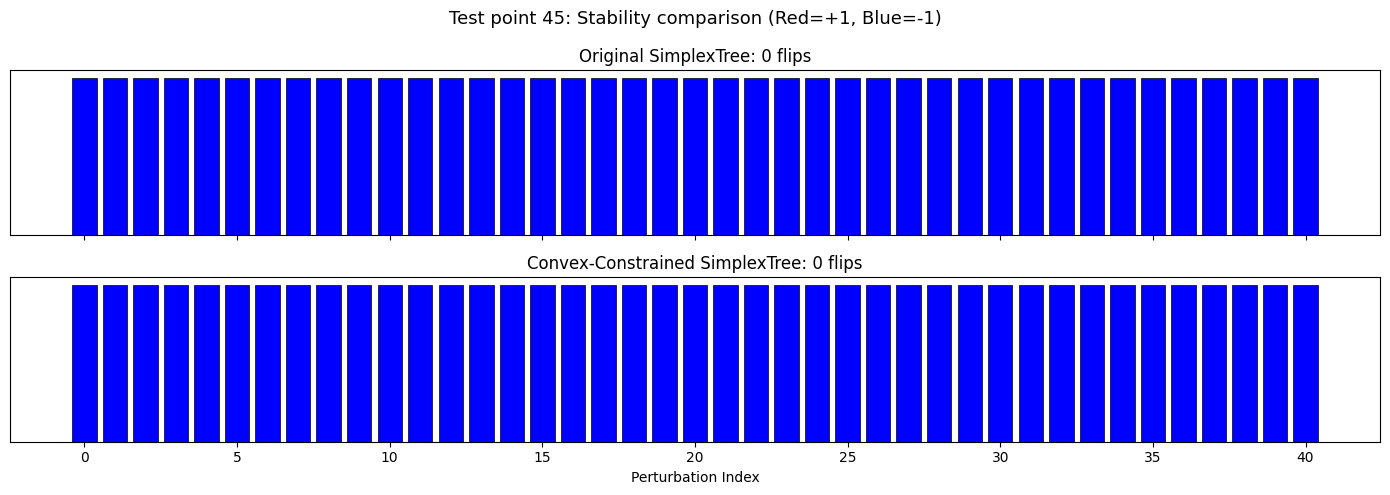

In [ ]:
# Compare instability of original vs convex tree on the same chosen point
if len(top_unstable_idx) > 0:
    np.random.seed(0)
    orig_preds_seq = demonstrate_instability(
        stc, chosen_point, noise_std=0.02, n_perturbations=40
    )
    np.random.seed(0)
    convex_preds_seq = demonstrate_instability(
        stc_convex, chosen_point, noise_std=0.02, n_perturbations=40
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

    # Original tree
    pred_vals_orig = [p[1] for p in orig_preds_seq]
    colors_orig = ['red' if p == 1 else 'blue' for p in pred_vals_orig]
    ax1.bar(range(len(pred_vals_orig)), [1]*len(pred_vals_orig), 
            color=colors_orig, edgecolor='k', linewidth=0.5)
    flips_orig = sum(1 for i in range(1, len(pred_vals_orig)) if pred_vals_orig[i] != pred_vals_orig[i-1])
    ax1.set_title(f'Original SimplexTree: {flips_orig} flips')
    ax1.set_yticks([])

    # Convex tree
    pred_vals_conv = [p[1] for p in convex_preds_seq]
    colors_conv = ['red' if p == 1 else 'blue' for p in pred_vals_conv]
    ax2.bar(range(len(pred_vals_conv)), [1]*len(pred_vals_conv), 
            color=colors_conv, edgecolor='k', linewidth=0.5)
    flips_conv = sum(1 for i in range(1, len(pred_vals_conv)) if pred_vals_conv[i] != pred_vals_conv[i-1])
    ax2.set_title(f'Convex-Constrained SimplexTree: {flips_conv} flips')
    ax2.set_xlabel('Perturbation Index')
    ax2.set_yticks([])

    plt.suptitle(f'Test point {chosen_idx}: Stability comparison (Red=+1, Blue=-1)', fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Stability Summary & Visualization

We compare the flip-rate distributions of the original and convex-constrained trees,
and project data to 2D using PCA for visual intuition.

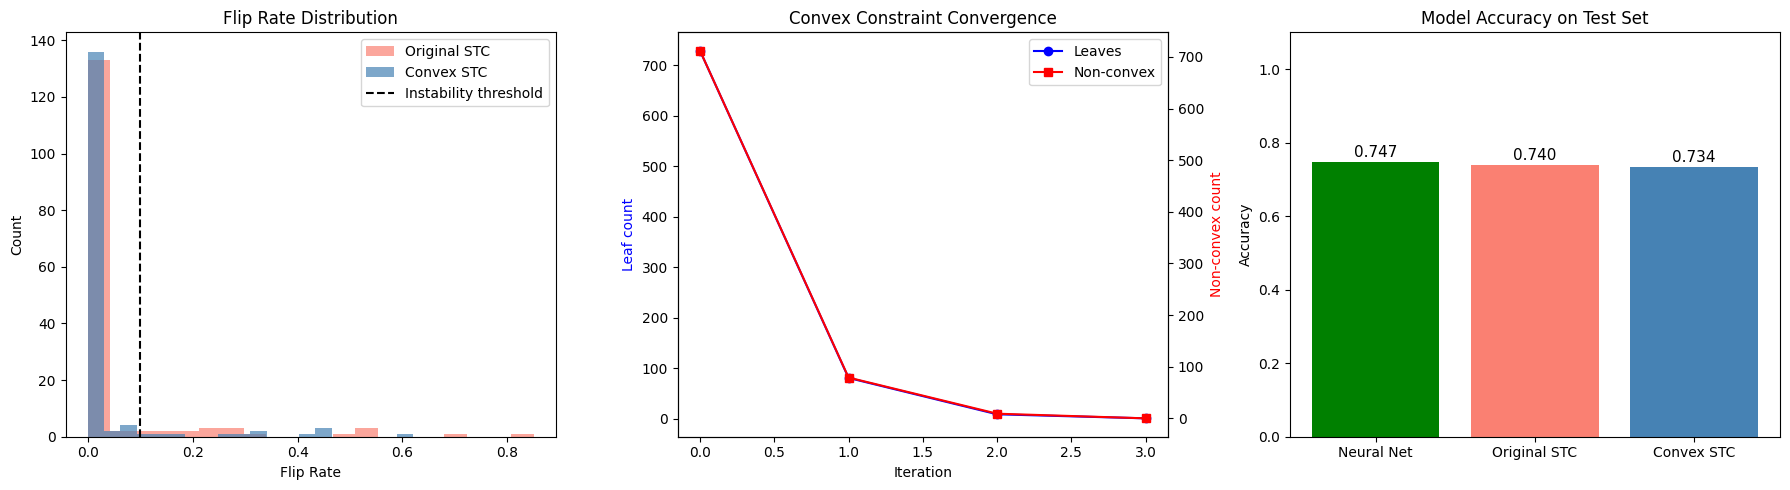

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Flip rate distributions
axes[0].hist(stc_flip_rate, bins=20, alpha=0.7, label='Original STC', color='salmon')
axes[0].hist(convex_flip_rate, bins=20, alpha=0.7, label='Convex STC', color='steelblue')
axes[0].axvline(x=0.1, color='k', linestyle='--', label='Instability threshold')
axes[0].set_xlabel('Flip Rate')
axes[0].set_ylabel('Count')
axes[0].set_title('Flip Rate Distribution')
axes[0].legend()

# Convergence: leaves and non-convex count per iteration
if convex_history:
    iters = [h['iteration'] for h in convex_history]
    leaves = [h['leaves'] for h in convex_history]
    nonconv = [h['nonconvex'] for h in convex_history]
    
    ax_left = axes[1]
    ax_right = ax_left.twinx()
    ax_left.plot(iters, leaves, 'b-o', label='Leaves')
    ax_right.plot(iters, nonconv, 'r-s', label='Non-convex')
    ax_left.set_xlabel('Iteration')
    ax_left.set_ylabel('Leaf count', color='b')
    ax_right.set_ylabel('Non-convex count', color='r')
    axes[1].set_title('Convex Constraint Convergence')
    lines1, labels1 = ax_left.get_legend_handles_labels()
    lines2, labels2 = ax_right.get_legend_handles_labels()
    ax_left.legend(lines1 + lines2, labels1 + labels2)

# Accuracy comparison
models_names = ['Neural Net', 'Original STC', 'Convex STC']
y_nn_test_labels = nn_predict(nn_model, X_test)
accs = [
    accuracy_score(y_test, y_nn_test_labels),
    accuracy_score(y_test, stc.predict(X_test)),
    accuracy_score(y_test, stc_convex.predict(X_test)),
]
bars = axes[2].bar(models_names, accs, color=['green', 'salmon', 'steelblue'])
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Model Accuracy on Test Set')
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

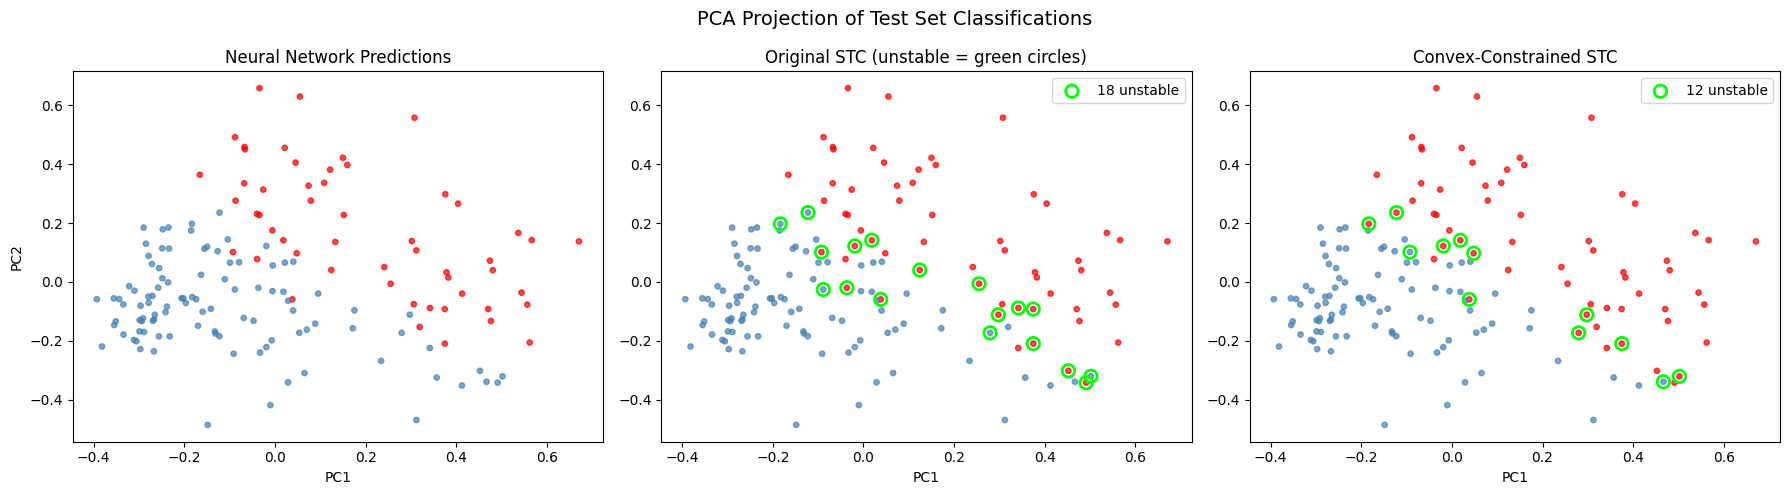

In [ ]:
# PCA projection to 2D for visualization
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NN predictions
y_nn_labels = nn_predict(nn_model, X_test)
colors_nn = ['red' if p == 1 else 'steelblue' for p in y_nn_labels]
axes[0].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors_nn, s=15, alpha=0.7)
axes[0].set_title('Neural Network Predictions')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Original STC predictions with unstable points highlighted
y_stc_labels = stc.predict(X_test)
colors_stc = ['red' if p == 1 else 'steelblue' for p in y_stc_labels]
axes[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors_stc, s=15, alpha=0.7)
unstable_2d = X_test_2d[stc_unstable_mask]
if len(unstable_2d) > 0:
    axes[1].scatter(unstable_2d[:, 0], unstable_2d[:, 1], 
                    facecolors='none', edgecolors='lime', s=80, linewidths=2,
                    label=f'{len(unstable_2d)} unstable')
    axes[1].legend()
axes[1].set_title('Original STC (unstable = green circles)')
axes[1].set_xlabel('PC1')

# Convex STC predictions
y_conv_labels = stc_convex.predict(X_test)
colors_conv = ['red' if p == 1 else 'steelblue' for p in y_conv_labels]
axes[2].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors_conv, s=15, alpha=0.7)
conv_unstable_2d = X_test_2d[convex_unstable_mask]
if len(conv_unstable_2d) > 0:
    axes[2].scatter(conv_unstable_2d[:, 0], conv_unstable_2d[:, 1],
                    facecolors='none', edgecolors='lime', s=80, linewidths=2,
                    label=f'{len(conv_unstable_2d)} unstable')
    axes[2].legend()
axes[2].set_title('Convex-Constrained STC')
axes[2].set_xlabel('PC1')

plt.suptitle('PCA Projection of Test Set Classifications', fontsize=14)
plt.tight_layout()
plt.show()

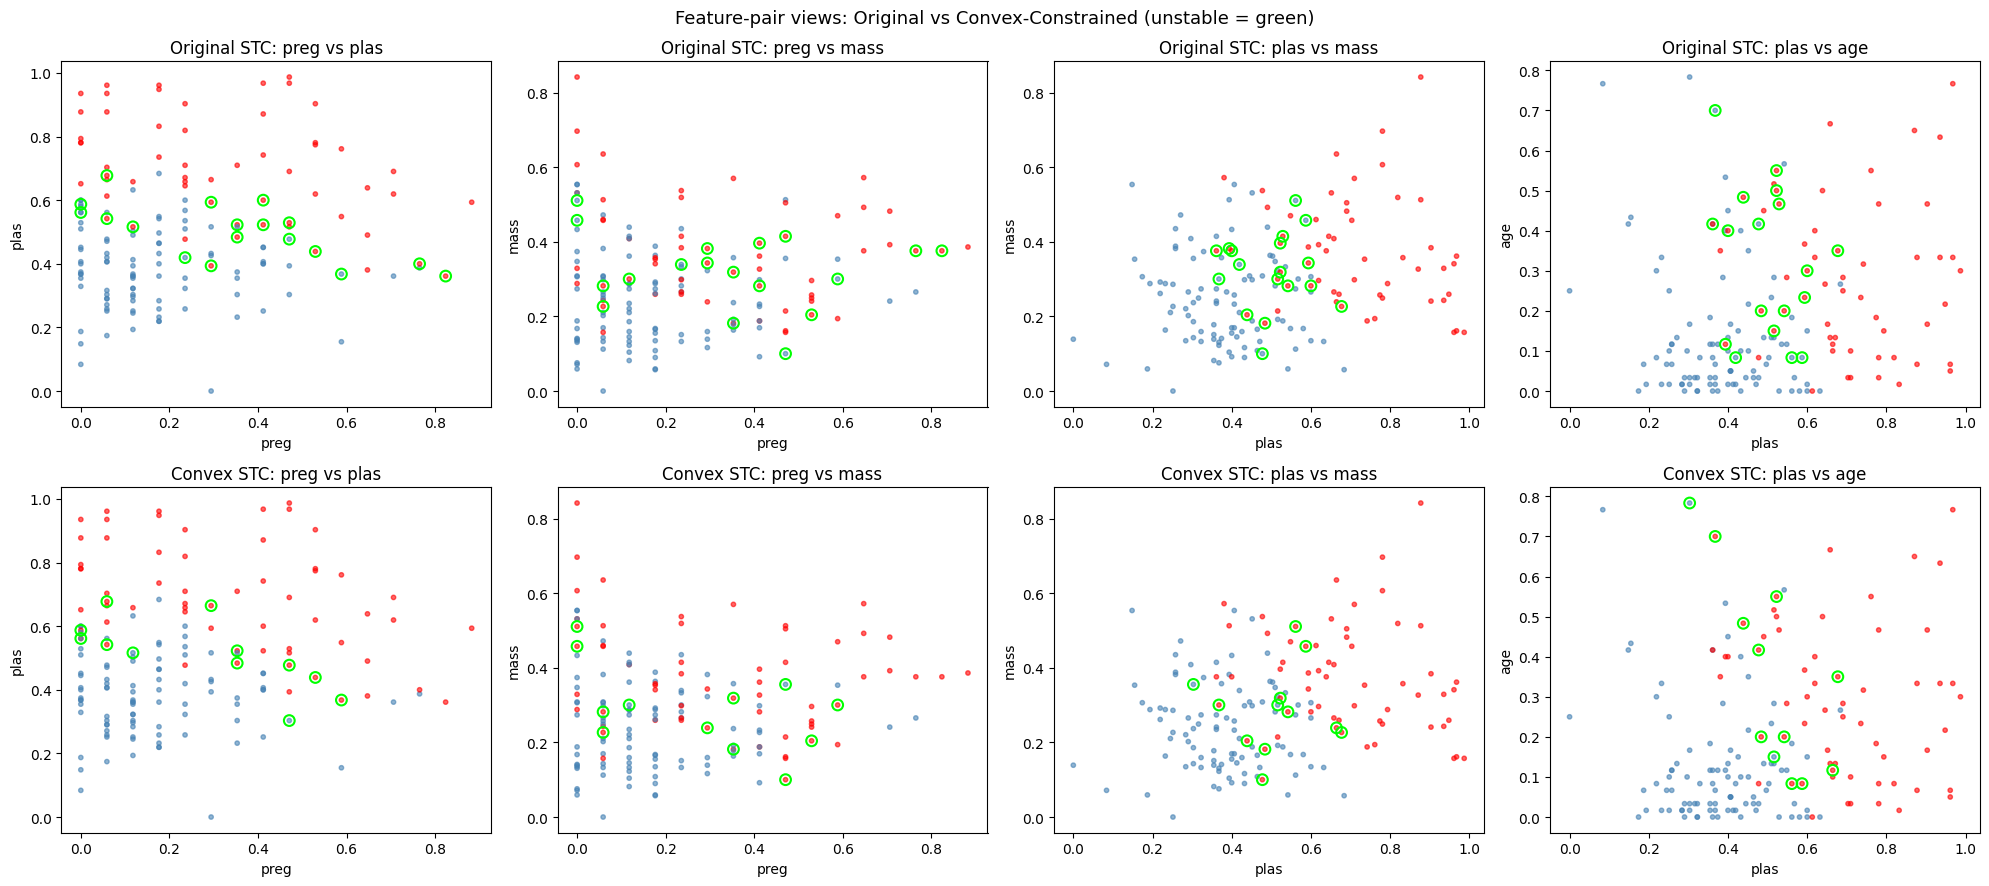

In [ ]:
# Pairwise feature plots for selected feature pairs
feature_names = list(diabetes.data.columns) if hasattr(diabetes.data, 'columns') else [f'F{i}' for i in range(n_features)]
pairs = [(0, 1), (0, 5), (1, 5), (1, 7)]  # (preg, plas), (preg, mass), (plas, mass), (plas, age)

fig, axes = plt.subplots(2, len(pairs), figsize=(5*len(pairs), 9))

for col, (fi, fj) in enumerate(pairs):
    fname_i = feature_names[fi] if fi < len(feature_names) else f'F{fi}'
    fname_j = feature_names[fj] if fj < len(feature_names) else f'F{fj}'
    
    # Original STC
    ax = axes[0, col]
    colors_o = ['red' if p == 1 else 'steelblue' for p in stc.predict(X_test)]
    ax.scatter(X_test[:, fi], X_test[:, fj], c=colors_o, s=10, alpha=0.6)
    unstable_pts = X_test[stc_unstable_mask]
    if len(unstable_pts) > 0:
        ax.scatter(unstable_pts[:, fi], unstable_pts[:, fj],
                   facecolors='none', edgecolors='lime', s=60, linewidths=1.5)
    ax.set_xlabel(fname_i)
    ax.set_ylabel(fname_j)
    ax.set_title(f'Original STC: {fname_i} vs {fname_j}')
    
    # Convex STC
    ax = axes[1, col]
    colors_c = ['red' if p == 1 else 'steelblue' for p in stc_convex.predict(X_test)]
    ax.scatter(X_test[:, fi], X_test[:, fj], c=colors_c, s=10, alpha=0.6)
    conv_unstable_pts = X_test[convex_unstable_mask]
    if len(conv_unstable_pts) > 0:
        ax.scatter(conv_unstable_pts[:, fi], conv_unstable_pts[:, fj],
                   facecolors='none', edgecolors='lime', s=60, linewidths=1.5)
    ax.set_xlabel(fname_i)
    ax.set_ylabel(fname_j)
    ax.set_title(f'Convex STC: {fname_i} vs {fname_j}')

plt.suptitle('Feature-pair views: Original vs Convex-Constrained (unstable = green)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Summary Table

In [ ]:
print('=' * 70)
print('RESULTS SUMMARY')
print('=' * 70)
print(f'\nDataset: Pima Indians Diabetes ({X.shape[0]} samples, {n_features} features)')
print(f'Neural Network: 4-layer MLP (64-32-16-1) with ReLU & Dropout')
print(f'SimplexTree: {SUBDIVISION_LEVELS} subdivision levels, C={C_PARAM}')
print(f'Fill points for boundary approximation: {N_FILL}')
print(f'\n{"Metric":35s} {"NN":>10s} {"Orig STC":>10s} {"Convex STC":>10s}')
print('-' * 70)
print(f'{"Test accuracy vs true labels:":35s} '
      f'{accuracy_score(y_test, nn_predict(nn_model, X_test)):>10.4f} '
      f'{accuracy_score(y_test, stc.predict(X_test)):>10.4f} '
      f'{accuracy_score(y_test, stc_convex.predict(X_test)):>10.4f}')
print(f'{"Agreement with NN:":35s} '
      f'{"---":>10s} '
      f'{accuracy_score(nn_predict(nn_model, X_test), stc.predict(X_test)):>10.4f} '
      f'{accuracy_score(nn_predict(nn_model, X_test), stc_convex.predict(X_test)):>10.4f}')
print(f'{"Unstable points (flip rate>10%):":35s} '
      f'{nn_unstable_mask.sum():>10d} '
      f'{stc_unstable_mask.sum():>10d} '
      f'{convex_unstable_mask.sum():>10d}')
print(f'{"Mean flip rate:":35s} '
      f'{nn_flip_rate.mean():>10.4f} '
      f'{stc_flip_rate.mean():>10.4f} '
      f'{convex_flip_rate.mean():>10.4f}')
print(f'{"Max flip rate:":35s} '
      f'{nn_flip_rate.max():>10.4f} '
      f'{stc_flip_rate.max():>10.4f} '
      f'{convex_flip_rate.max():>10.4f}')
print(f'{"Leaf simplices:":35s} '
      f'{"---":>10s} '
      f'{len(stc.leaf_simplexes):>10d} '
      f'{len(stc_convex.leaf_simplexes):>10d}')
print('=' * 70)

RESULTS SUMMARY

Dataset: Pima Indians Diabetes (768 samples, 8 features)
Neural Network: 4-layer MLP (64-32-16-1) with ReLU & Dropout
SimplexTree: 3 subdivision levels, C=10000
Fill points for boundary approximation: 5000

Metric                                      NN   Orig STC Convex STC
----------------------------------------------------------------------
Test accuracy vs true labels:           0.7468     0.7403     0.7338
Agreement with NN:                         ---     0.9545     0.9351
Unstable points (flip rate>10%):            10         18         12
Mean flip rate:                         0.0256     0.0428     0.0296
Max flip rate:                          0.4900     0.8500     0.6200
Leaf simplices:                            ---        729          1
